<a href="https://colab.research.google.com/github/Raffy0-1/CodeAlpha-Credit-Scoring-Model/blob/main/credit_scoring_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scoring Model - Production-Ready Implementation

## Project Overview
**Objective**: Build a robust credit scoring system to predict creditworthiness

**Dataset**: German Credit Data (1000 samples, 20+ features)

**Models**: Logistic Regression, Decision Tree, Random Forest

**Key Focus Areas**:
1. Advanced feature engineering
2. Model comparison & hyperparameter tuning
3. Business interpretation & deployment readiness
4. GPU-efficient operations with Google Drive persistence

## 1. Environment Setup & Google Drive Integration

In [ ]:
# Mount Google Drive for model persistence
from google.colab import drive
drive.mount('/content/drive')

# Create project directory structure
import os
PROJECT_DIR = '/content/drive/MyDrive/CreditScoringProject'
MODELS_DIR = f'{PROJECT_DIR}/models'
DATA_DIR = f'{PROJECT_DIR}/data'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for directory in [PROJECT_DIR, MODELS_DIR, DATA_DIR, RESULTS_DIR]:
    os.makedirs(directory, exist_ok=True)

print(f"✓ Project structure created at: {PROJECT_DIR}")

Mounted at /content/drive
✓ Project structure created at: /content/drive/MyDrive/CreditScoringProject


In [ ]:
# Install and import required libraries (latest compatible versions)
!pip install -q --upgrade ucimlrepo==0.0.7 imbalanced-learn optuna shap

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score
)

# Advanced tools
from imblearn.over_sampling import SMOTE
import optuna
import shap
from ucimlrepo import fetch_ucirepo

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ All libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.0 MB/s eta 0:00:00
✓ All libraries imported successfully


## 2. Data Loading & Initial Understanding

**German Credit Dataset Details**:
- 1000 instances
- 20 attributes (7 numerical, 13 categorical)
- Target: 1 = Good Credit, 2 = Bad Credit
- Imbalanced: ~70% good, 30% bad credit

In [ ]:
# Load German Credit Data from UCI Repository
statlog_german_credit = fetch_ucirepo(id=144)

# Extract features and target
X = statlog_german_credit.data.features
y = statlog_german_credit.data.targets

# Convert target to binary: 1 (good) -> 1, 2 (bad) -> 0
y = y['class'].map({1: 1, 2: 0})

# Create full dataframe
df = pd.concat([X, y.rename('credit_risk')], axis=1)

# Save raw data to Drive
df.to_csv(f'{DATA_DIR}/raw_data.csv', index=False)

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{y.value_counts(normalize=True)}")
print(f"\nFeature types:\n{df.dtypes.value_counts()}")

Dataset shape: (1000, 21)

Target distribution:
class
1    0.7
0    0.3
Name: proportion, dtype: float64

Feature types:
object    13
int64      8
Name: count, dtype: int64


In [ ]:
# Display dataset info
print("Dataset Info:")
print(df.info())
print("First few rows:")
df.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  Attribute19  1000 non-null   object
 19  Attribute20  1

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


In [ ]:
# Statistical summary
print("Numerical Features Summary:")
df.describe()

Numerical Features Summary:


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [ ]:
# Check for missing values
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print("Missing values found:")
    print(missing_data[missing_data > 0])
else:
    print("No missing values detected")

No missing values detected


## 3. Exploratory Data Analysis (EDA)

**Purpose**: Understand patterns, relationships, and potential issues in data

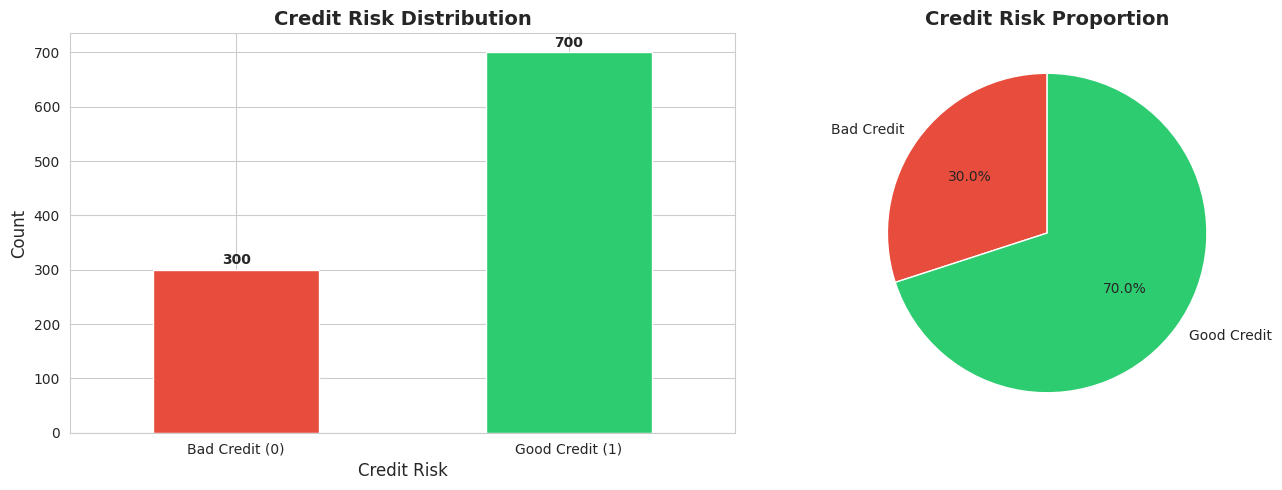

Class imbalance ratio: 2.33:1


In [ ]:
# Get the counts and sort by index (0 then 1) to ensure consistency
counts = y.value_counts().sort_index()

# Define explicit color mapping
# 0 = Bad (Red), 1 = Good (Green)
color_map = {0: '#e74c3c', 1: '#2ecc71'}
colors = [color_map[x] for x in counts.index]

# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Count plot
ax1 = axes[0]
counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Credit Risk Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Credit Risk', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

# Set labels for 0 and 1
ax1.set_xticklabels(['Bad Credit (0)', 'Good Credit (1)'], rotation=0)

# Add counts on bars
for i, v in enumerate(counts):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Percentage plot
ax2 = axes[1]
counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%',
            colors=colors, labels=['Bad Credit', 'Good Credit'],
            startangle=90)
ax2.set_title('Credit Risk Proportion', fontsize=14, fontweight='bold')
ax2.set_ylabel('') # Remove default ylabel

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print ratio using explicit indices to avoid errors
print(f"Class imbalance ratio: {counts[1] / counts[0]:.2f}:1")

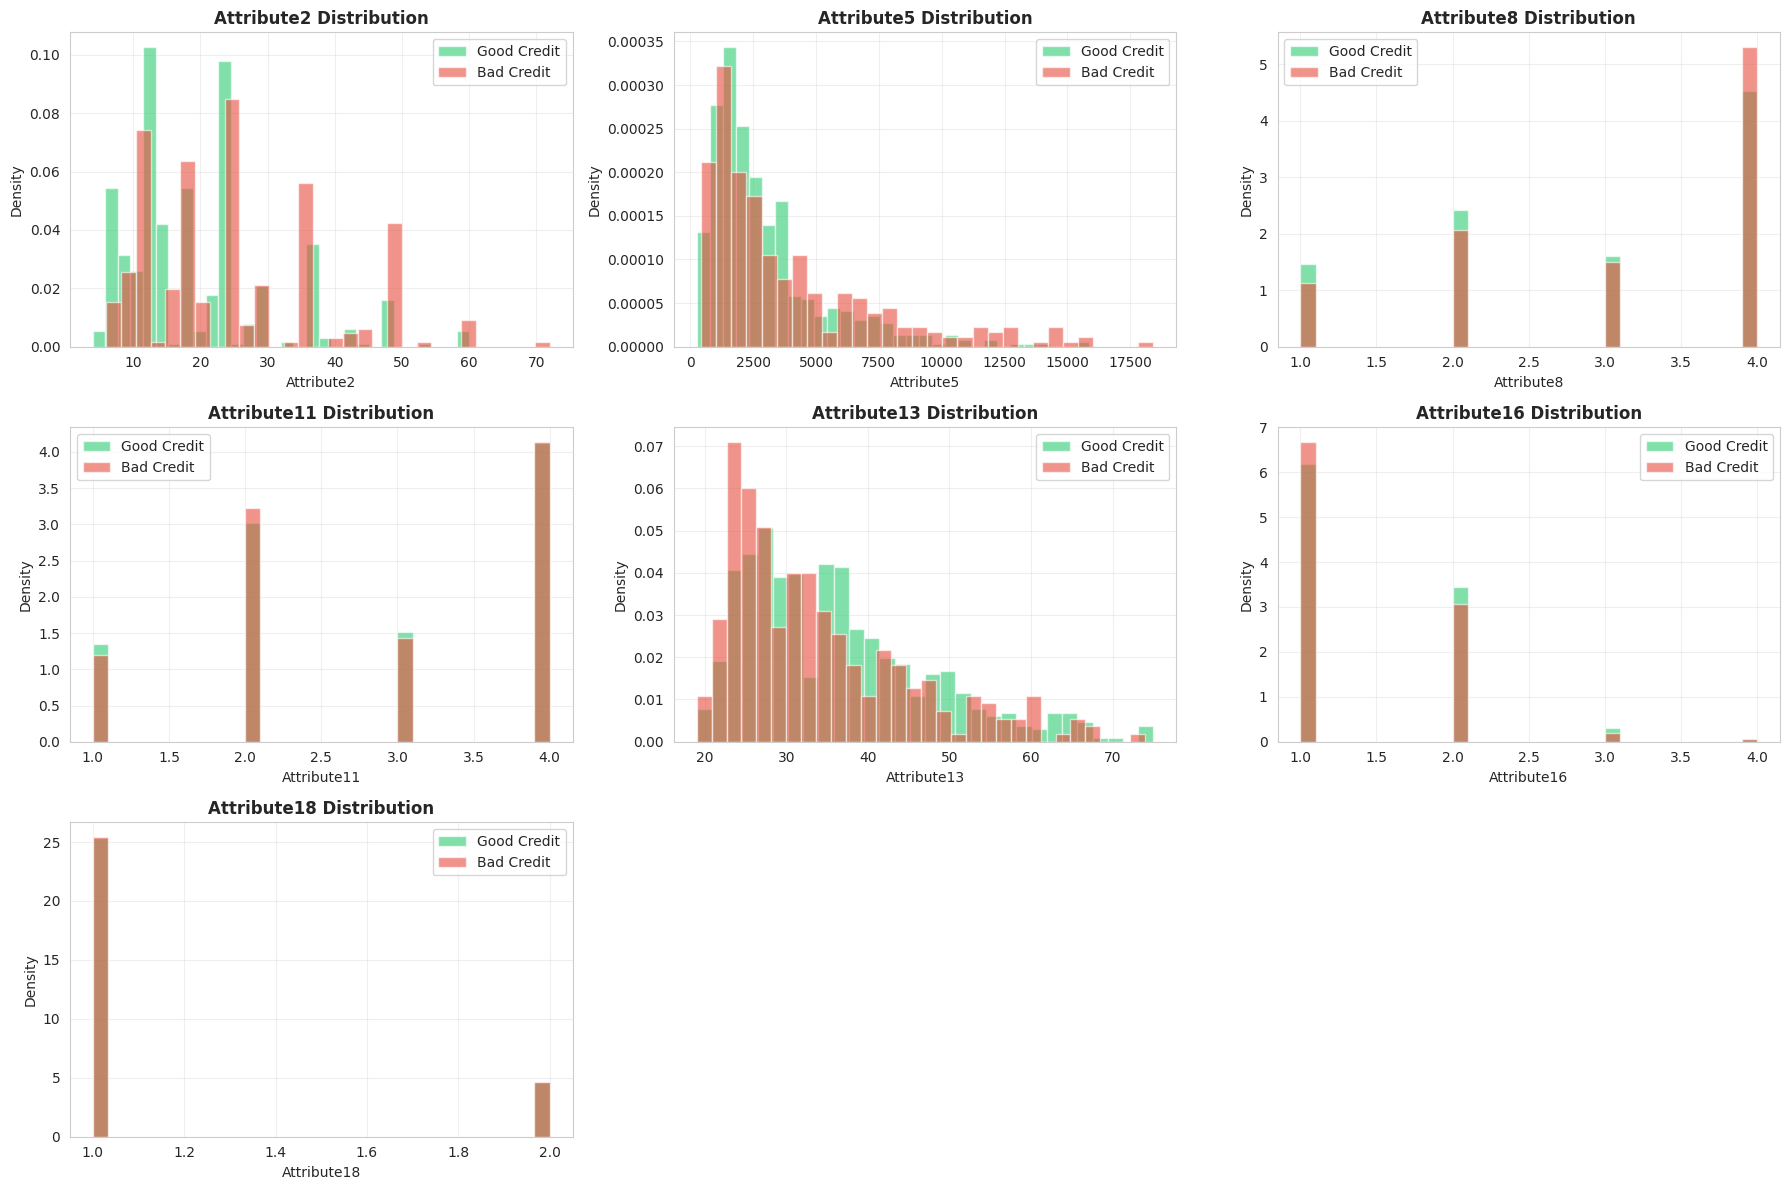

In [ ]:
# Numerical features distribution
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('credit_risk')

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]

    # Histogram with KDE
    df[df['credit_risk'] == 1][col].hist(ax=ax, alpha=0.6, bins=30,
                                           label='Good Credit', color='#2ecc71', density=True)
    df[df['credit_risk'] == 0][col].hist(ax=ax, alpha=0.6, bins=30,
                                           label='Bad Credit', color='#e74c3c', density=True)

    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

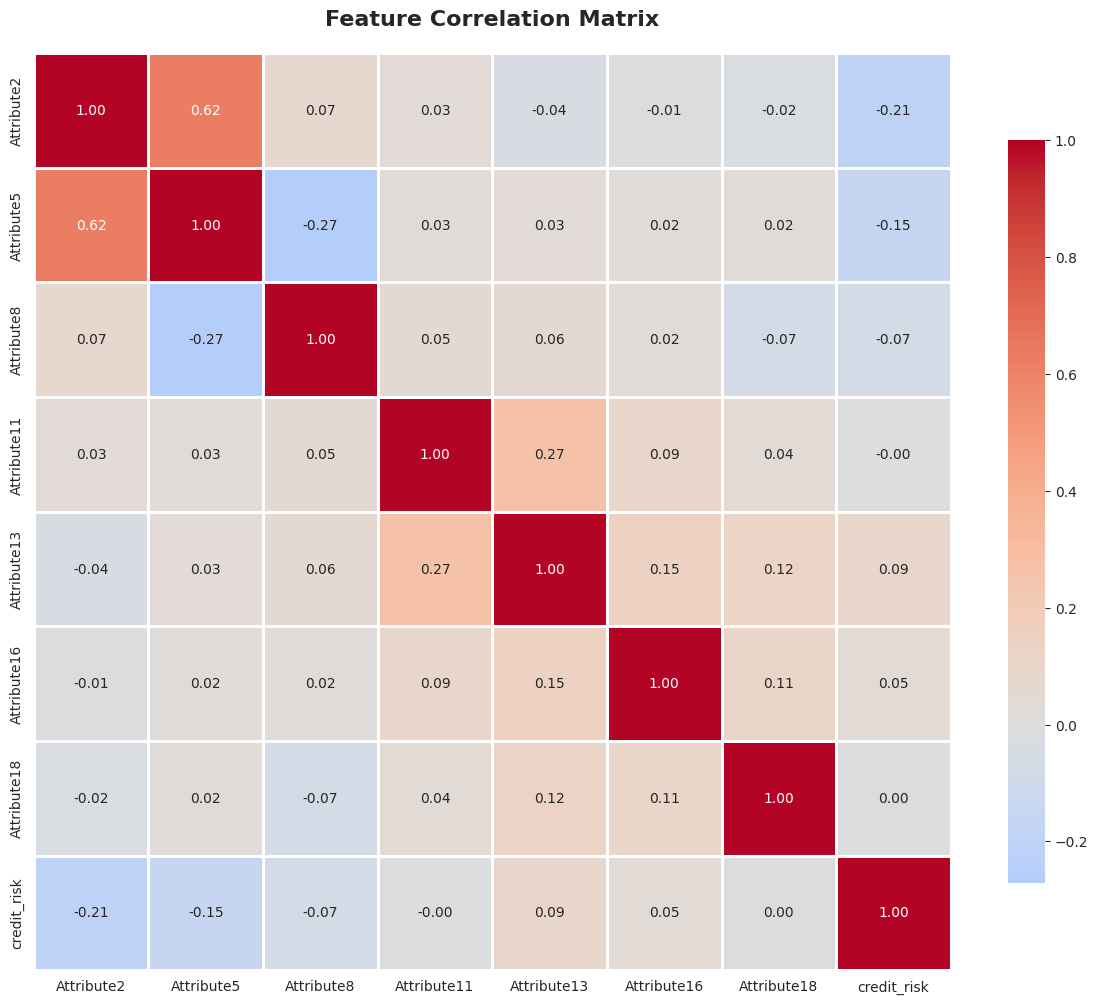


Top 10 features correlated with credit risk:
Attribute13    0.091127
Attribute16    0.045732
Attribute18    0.003015
Attribute11   -0.002967
Attribute8    -0.072404
Attribute5    -0.154739
Attribute2    -0.214927
Name: credit_risk, dtype: float64


In [ ]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols + ['credit_risk']].corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Top correlations with target
print("\nTop 10 features correlated with credit risk:")
print(correlation_matrix['credit_risk'].sort_values(ascending=False)[1:11])

Categorical features: 13
Features: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7']...


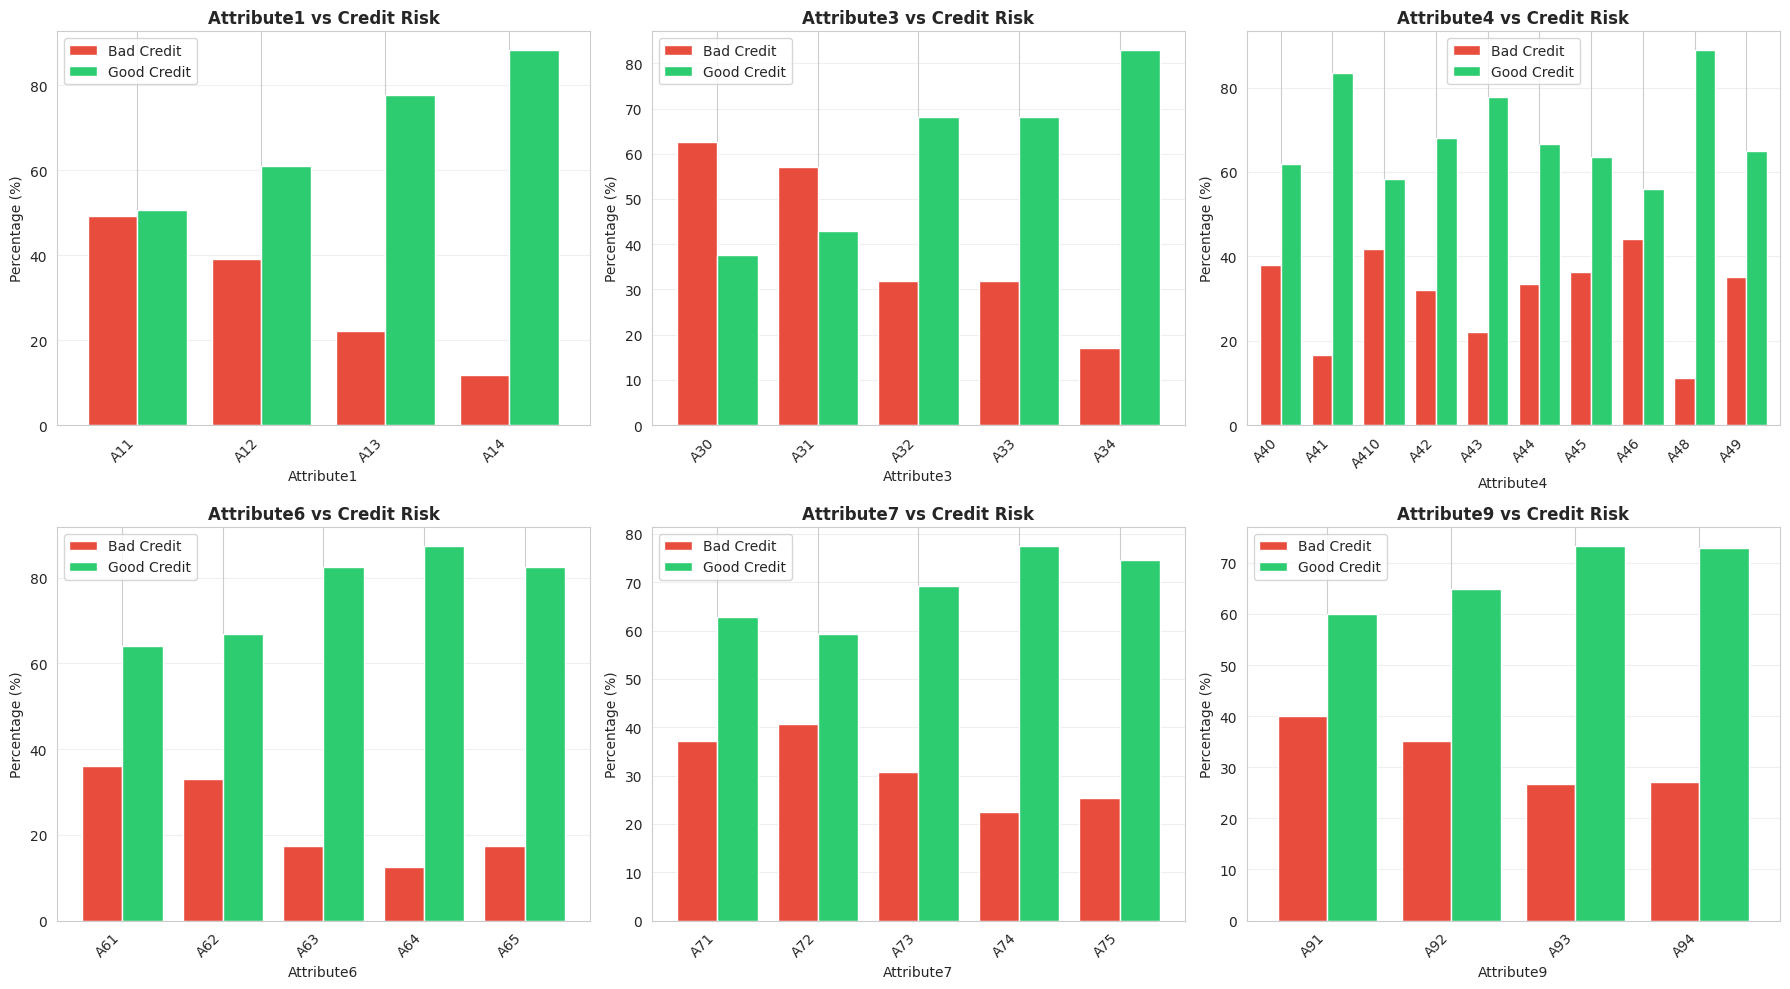

In [ ]:
# Categorical features analysis
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical features: {len(categorical_cols)}")
print(f"Features: {categorical_cols[:5]}...")  # Show first 5

# Analyze top categorical features by their relationship with target
top_cat_features = categorical_cols[:6]  # Analyze first 6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(top_cat_features):
    ax = axes[idx]

    # Create crosstab
    ct = pd.crosstab(df[col], df['credit_risk'], normalize='index') * 100

    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], width=0.8)
    ax.set_title(f'{col} vs Credit Risk', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage (%)')
    ax.legend(['Bad Credit', 'Good Credit'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Advanced Feature Engineering

**Strategy**:
1. Encode categorical variables (One-Hot, Label Encoding)
2. Create domain-specific features (debt ratios, risk indicators)
3. Polynomial features for non-linear relationships
4. Feature scaling for distance-based algorithms

In [ ]:
# Separate features and target
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1000, 20)
Target shape: (1000,)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import json

# Feature engineering function
def engineer_features(X_data, fit=True, encoders=None):
    """
    Advanced feature engineering pipeline

    Args:
        X_data: Input features
        fit: Whether to fit encoders (True for train, False for test)
        encoders: Pre-fitted encoders for test data

    Returns:
        Processed features and encoders
    """
    X_eng = X_data.copy()

    # 1. Create domain-specific features (if numerical columns exist)
    # Example: Debt-to-income ratio, credit utilization, etc.
    # Note: German Credit Data column names are generic (Attribute1, Attribute2, etc.)
    # In production, you'd use actual column names like 'loan_amount', 'income', etc.

    numerical_features = X_eng.select_dtypes(include=[np.number]).columns

    if 'Attribute2' in X_eng.columns and 'Attribute5' in X_eng.columns:
        # Duration to amount ratio
        X_eng['duration_amount_ratio'] = X_eng['Attribute2'] / (X_eng['Attribute5'] + 1)

    if 'Attribute8' in X_eng.columns and 'Attribute13' in X_eng.columns:
        # Age to installment rate ratio
        X_eng['age_installment_ratio'] = X_eng['Attribute13'] / (X_eng['Attribute8'] + 1)

    # 2. Encode categorical variables
    # Get initial categorical features before any processing
    current_categorical_features = X_eng.select_dtypes(include=['object']).columns.tolist()

    if fit:
        encoders = {}

        # One-Hot Encoding for low cardinality features
        low_cardinality = [col for col in current_categorical_features
                          if X_eng[col].nunique() <= 5]

        if low_cardinality:
            X_eng = pd.get_dummies(X_eng, columns=low_cardinality, drop_first=True)
            encoders['one_hot_cols'] = low_cardinality

        # After one-hot encoding, update the list of categorical features
        # to only include those that are still object type columns in X_eng.
        current_categorical_features = X_eng.select_dtypes(include=['object']).columns.tolist()

        # Label Encoding for high cardinality features
        high_cardinality = [col for col in current_categorical_features
                           if X_eng[col].nunique() > 5]

        label_encoders = {}
        for col in high_cardinality:
            le = LabelEncoder()
            X_eng[col] = le.fit_transform(X_eng[col].astype(str))
            label_encoders[col] = le

        encoders['label_encoders'] = label_encoders

    else:
        # Apply pre-fitted encoders
        if 'one_hot_cols' in encoders:
            # For test data, ensure all dummy variables from training are created.
            # Using `pd.get_dummies` with `columns` argument will drop original columns
            # and create new ones. If a column is missing in `X_data` but in `one_hot_cols`,
            # `get_dummies` will ignore it, which might lead to feature mismatch.
            # A more robust solution might involve aligning columns explicitly later.
            X_eng = pd.get_dummies(X_eng, columns=encoders['one_hot_cols'], drop_first=True)

        if 'label_encoders' in encoders:
            for col, le in encoders['label_encoders'].items():
                if col in X_eng.columns:
                    X_eng[col] = le.transform(X_eng[col].astype(str))
                else:
                    # Handle cases where a label-encoded column might be missing in test data.
                    # For now, we'll assume consistency or let downstream errors occur if vital.
                    print(f"Warning: Label encoded column '{col}' not found in test data. Skipping transformation.")

    return X_eng, encoders

# Apply feature engineering
X_engineered, feature_encoders = engineer_features(X, fit=True)

print(f"Original features: {X.shape[1]}")
print(f"Engineered features: {X_engineered.shape[1]}")
print(f"\nNew feature columns: {X_engineered.shape[1] - X.shape[1]} added")

# Save feature names
feature_names = X_engineered.columns.tolist()
with open(f'{DATA_DIR}/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f"\nFeature names saved to Drive")

Original features: 20
Engineered features: 42

New feature columns: 22 added

Feature names saved to Drive


## 5. Train-Test Split & Data Preparation

**Strategy**:
- Stratified split to maintain class distribution
- 80-20 train-test split
- SMOTE for handling class imbalance (applied only on training data)

In [ ]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Test Split:")
print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"Testing samples: {X_test.shape[0]} ({X_test.shape[0]/len(X_engineered)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Train-Test Split:
Training samples: 800 (80.0%)
Testing samples: 200 (20.0%)

Training set class distribution:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64

Test set class distribution:
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Features scaled using StandardScaler")
print(f"\nScaled feature statistics (training set):")
print(f"Mean: {X_train_scaled.mean().mean():.4f}")
print(f"Std: {X_train_scaled.std().mean():.4f}")

✓ Features scaled using StandardScaler

Scaled feature statistics (training set):
Mean: 0.0000
Std: 1.0006


SMOTE Resampling Results:
Original training samples: 800
Balanced training samples: 1120

Balanced class distribution:
credit_risk
1    0.5
0    0.5
Name: proportion, dtype: float64


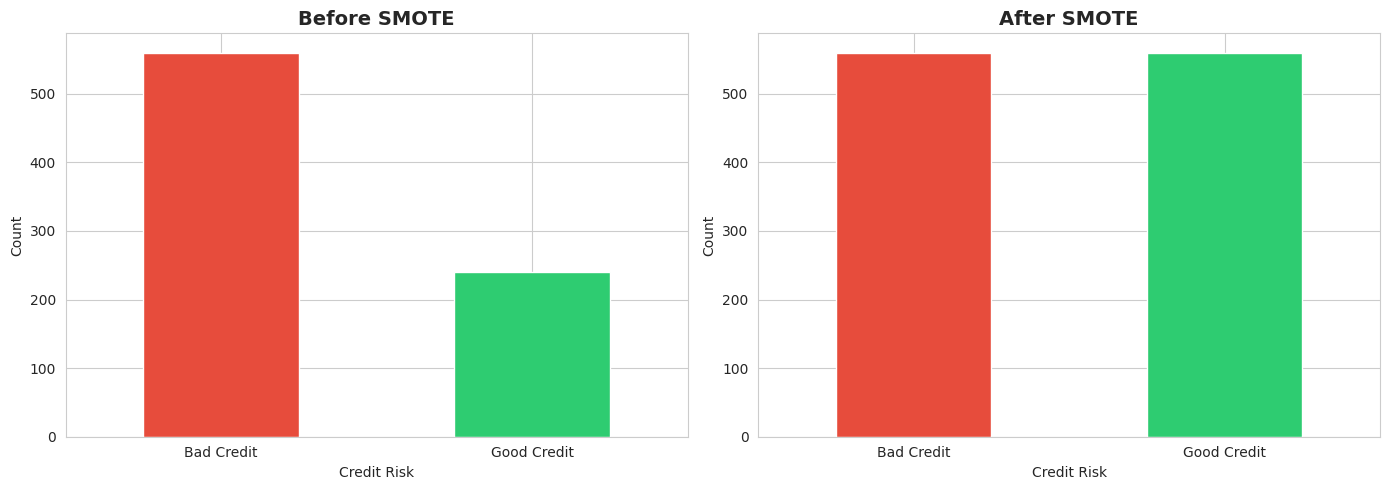

In [ ]:
# Handle class imbalance with SMOTE (only on training data)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE Resampling Results:")
print(f"Original training samples: {len(y_train)}")
print(f"Balanced training samples: {len(y_train_balanced)}")
print(f"\nBalanced class distribution:")
print(y_train_balanced.value_counts(normalize=True))

# Visualize before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Credit Risk')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bad Credit', 'Good Credit'], rotation=0)

# After SMOTE
y_train_balanced.value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Credit Risk')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bad Credit', 'Good Credit'], rotation=0)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model Training & Evaluation Framework

**Models to Train**:
1. Logistic Regression (baseline)
2. Decision Tree (interpretable)
3. Random Forest (ensemble, high performance)

**Evaluation Metrics**:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC (primary metric for imbalanced data)
- Confusion Matrix
- Cross-validation scores

In [ ]:
# Define evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Comprehensive model evaluation with multiple metrics

    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        model_name: Name for reporting

    Returns:
        Dictionary of metrics
    """
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probability predictions (for ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        y_proba_train = y_pred_train
        y_proba_test = y_pred_test

    # Calculate metrics
    metrics = {
        'model': model_name,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'train_precision': precision_score(y_train, y_pred_train),
        'test_precision': precision_score(y_test, y_pred_test),
        'train_recall': recall_score(y_train, y_pred_train),
        'test_recall': recall_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train),
        'test_f1': f1_score(y_test, y_pred_test),
        'train_roc_auc': roc_auc_score(y_train, y_proba_train),
        'test_roc_auc': roc_auc_score(y_test, y_proba_test)
    }

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    metrics['cv_roc_auc_mean'] = cv_scores.mean()
    metrics['cv_roc_auc_std'] = cv_scores.std()

    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"\n{'Metric':<25} {'Train':<15} {'Test':<15}")
    print(f"{'-'*60}")
    print(f"{'Accuracy':<25} {metrics['train_accuracy']:<15.4f} {metrics['test_accuracy']:<15.4f}")
    print(f"{'Precision':<25} {metrics['train_precision']:<15.4f} {metrics['test_precision']:<15.4f}")
    print(f"{'Recall':<25} {metrics['train_recall']:<15.4f} {metrics['test_recall']:<15.4f}")
    print(f"{'F1-Score':<25} {metrics['train_f1']:<15.4f} {metrics['test_f1']:<15.4f}")
    print(f"{'ROC-AUC':<25} {metrics['train_roc_auc']:<15.4f} {metrics['test_roc_auc']:<15.4f}")
    print(f"\n{'Cross-Validation ROC-AUC':<25} {metrics['cv_roc_auc_mean']:.4f} ± {metrics['cv_roc_auc_std']:.4f}")

    # Classification report
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test, target_names=['Bad Credit', 'Good Credit']))

    return metrics, y_pred_test, y_proba_test

print("✓ Evaluation framework ready")

✓ Evaluation framework ready


### 6.1 Logistic Regression (Baseline Model)

In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0  # Regularization strength
)

lr_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
lr_metrics, lr_pred, lr_proba = evaluate_model(
    lr_model, X_train_balanced, y_train_balanced,
    X_test_scaled, y_test, 'Logistic Regression'
)

# Save model
joblib.dump(lr_model, f'{MODELS_DIR}/logistic_regression_model.pkl')
print("\n✓ Model saved to Google Drive")


Logistic Regression - Performance Metrics

Metric                    Train           Test           
------------------------------------------------------------
Accuracy                  0.7964          0.7050         
Precision                 0.8051          0.8522         
Recall                    0.7821          0.7000         
F1-Score                  0.7935          0.7686         
ROC-AUC                   0.8614          0.7696         

Cross-Validation ROC-AUC  0.8396 ± 0.0391

Classification Report (Test Set):
              precision    recall  f1-score   support

  Bad Credit       0.51      0.72      0.59        60
 Good Credit       0.85      0.70      0.77       140

    accuracy                           0.70       200
   macro avg       0.68      0.71      0.68       200
weighted avg       0.75      0.70      0.72       200


✓ Model saved to Google Drive


### 6.2 Decision Tree Classifier

In [ ]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    criterion='gini'
)

dt_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
dt_metrics, dt_pred, dt_proba = evaluate_model(
    dt_model, X_train_balanced, y_train_balanced,
    X_test_scaled, y_test, 'Decision Tree'
)

# Save model
joblib.dump(dt_model, f'{MODELS_DIR}/decision_tree_model.pkl')
print("\n✓ Model saved to Google Drive")


Decision Tree - Performance Metrics

Metric                    Train           Test           
------------------------------------------------------------
Accuracy                  0.8518          0.7200         
Precision                 0.8745          0.8182         
Recall                    0.8214          0.7714         
F1-Score                  0.8471          0.7941         
ROC-AUC                   0.9227          0.7462         

Cross-Validation ROC-AUC  0.8076 ± 0.0860

Classification Report (Test Set):
              precision    recall  f1-score   support

  Bad Credit       0.53      0.60      0.56        60
 Good Credit       0.82      0.77      0.79       140

    accuracy                           0.72       200
   macro avg       0.67      0.69      0.68       200
weighted avg       0.73      0.72      0.72       200


✓ Model saved to Google Drive


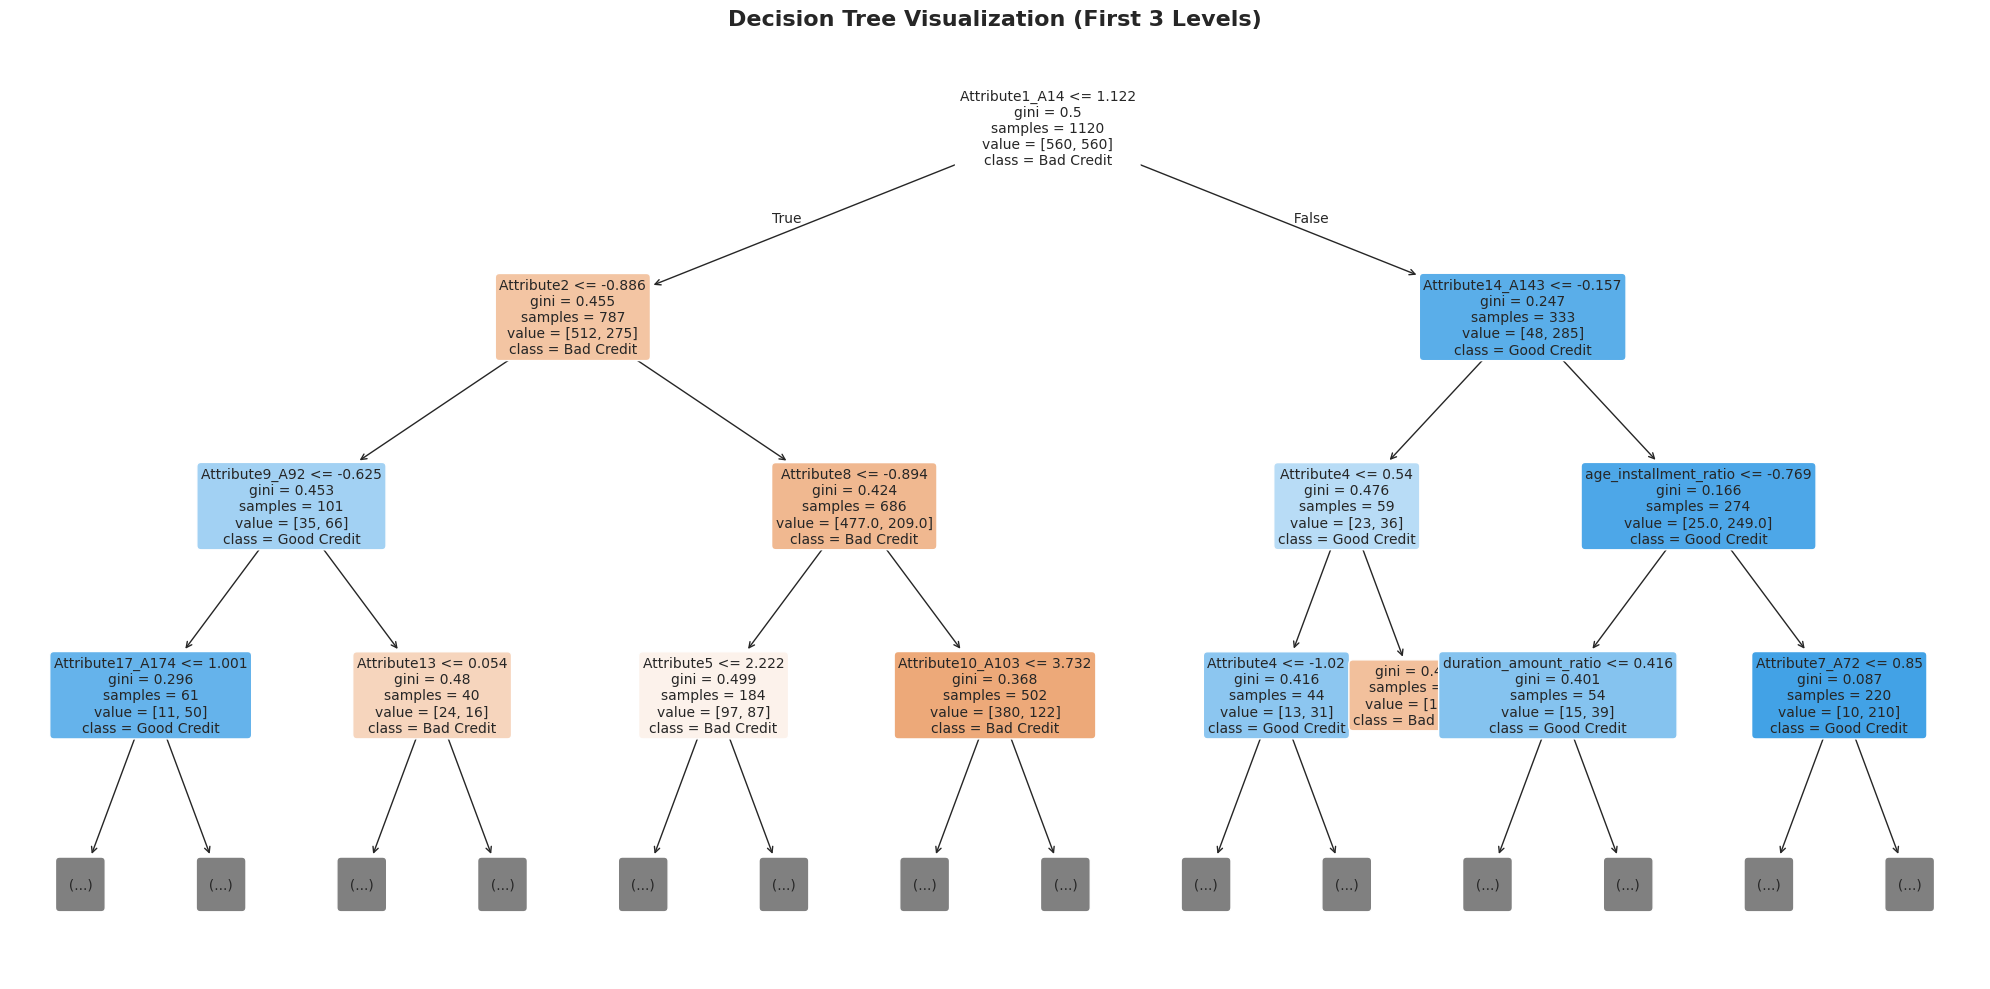

In [ ]:
# Visualize Decision Tree (first 3 levels only for readability)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=feature_names,
    class_names=['Bad Credit', 'Good Credit'],
    filled=True,
    fontsize=10,
    rounded=True
)
plt.title('Decision Tree Visualization (First 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/decision_tree_viz.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Random Forest Classifier

In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
rf_metrics, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train_balanced, y_train_balanced,
    X_test_scaled, y_test, 'Random Forest'
)

# Save model
joblib.dump(rf_model, f'{MODELS_DIR}/random_forest_model.pkl')
print("\n✓ Model saved to Google Drive")


Random Forest - Performance Metrics

Metric                    Train           Test           
------------------------------------------------------------
Accuracy                  0.9348          0.7000         
Precision                 0.9092          0.7941         
Recall                    0.9661          0.7714         
F1-Score                  0.9368          0.7826         
ROC-AUC                   0.9859          0.7945         

Cross-Validation ROC-AUC  0.8998 ± 0.0882

Classification Report (Test Set):
              precision    recall  f1-score   support

  Bad Credit       0.50      0.53      0.52        60
 Good Credit       0.79      0.77      0.78       140

    accuracy                           0.70       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.71      0.70      0.70       200


✓ Model saved to Google Drive


## 7. Model Comparison & Visualization

In [ ]:
# Compile all metrics
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics])
results_df = results_df.round(4)

print("\nModel Comparison Summary:")
print(results_df[['model', 'test_accuracy', 'test_precision', 'test_recall',
                  'test_f1', 'test_roc_auc', 'cv_roc_auc_mean']])

# Save results
results_df.to_csv(f'{RESULTS_DIR}/model_comparison.csv', index=False)
print("\n✓ Results saved to Google Drive")


Model Comparison Summary:
                 model  test_accuracy  test_precision  test_recall  test_f1  \
0  Logistic Regression          0.705          0.8522       0.7000   0.7686   
1        Decision Tree          0.720          0.8182       0.7714   0.7941   
2        Random Forest          0.700          0.7941       0.7714   0.7826   

   test_roc_auc  cv_roc_auc_mean  
0        0.7696           0.8396  
1        0.7462           0.8076  
2        0.7945           0.8998  

✓ Results saved to Google Drive


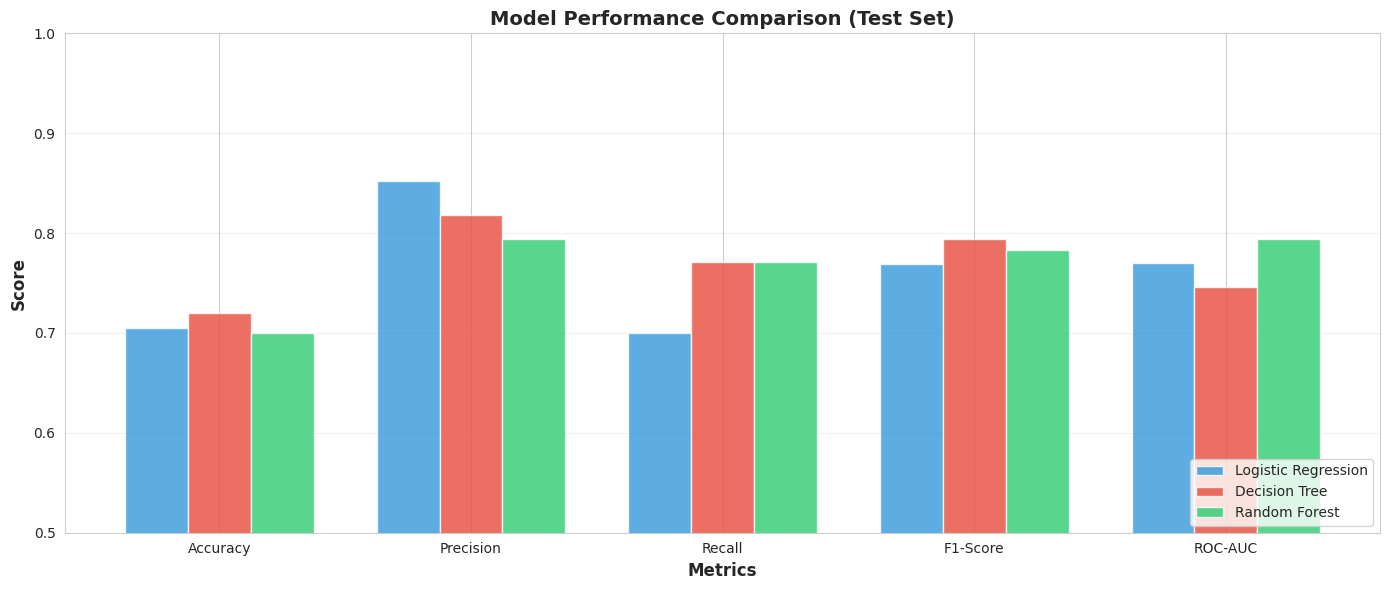

In [ ]:
# Visualization: Model Performance Comparison
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metric_labels))
width = 0.25

# Plot bars for each model
ax.bar(x - width, results_df.iloc[0][metrics_to_plot], width,
       label='Logistic Regression', color='#3498db', alpha=0.8)
ax.bar(x, results_df.iloc[1][metrics_to_plot], width,
       label='Decision Tree', color='#e74c3c', alpha=0.8)
ax.bar(x + width, results_df.iloc[2][metrics_to_plot], width,
       label='Random Forest', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

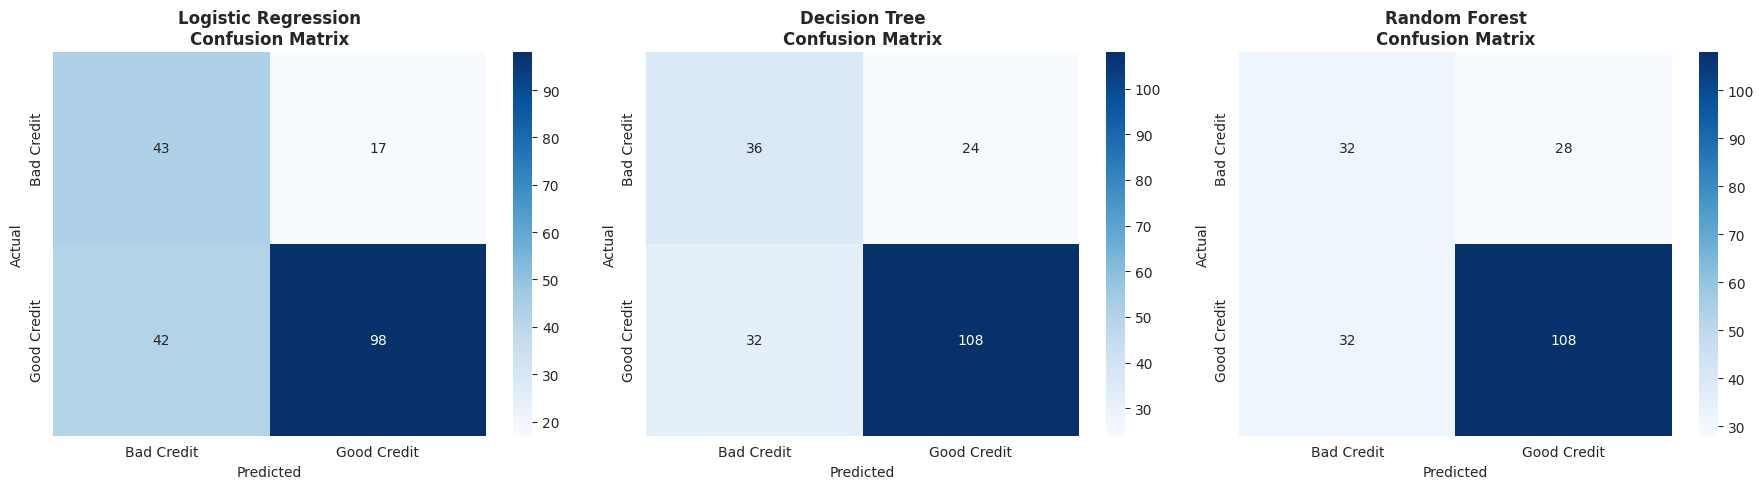

In [ ]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred)
]

for idx, (name, predictions) in enumerate(models_data):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bad Credit', 'Good Credit'],
                yticklabels=['Bad Credit', 'Good Credit'])

    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

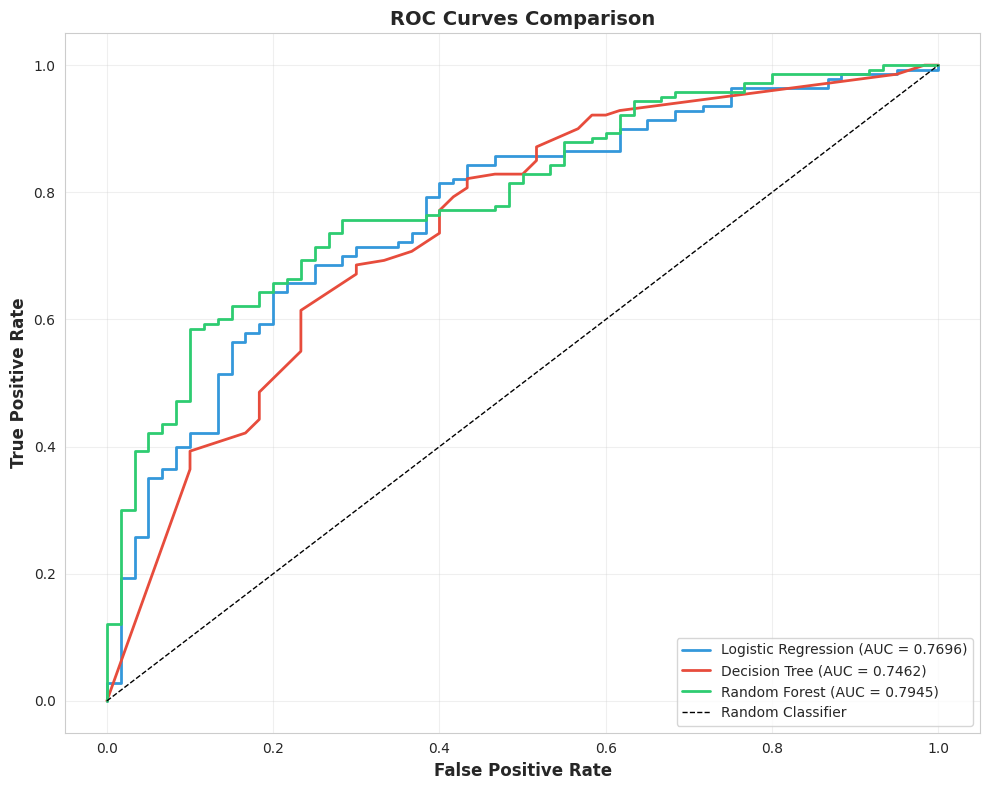

In [ ]:
# ROC Curves Comparison
plt.figure(figsize=(10, 8))

models_proba = [
    ('Logistic Regression', lr_proba, '#3498db'),
    ('Decision Tree', dt_proba, '#e74c3c'),
    ('Random Forest', rf_proba, '#2ecc71')
]

for name, proba, color in models_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, linewidth=2)

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

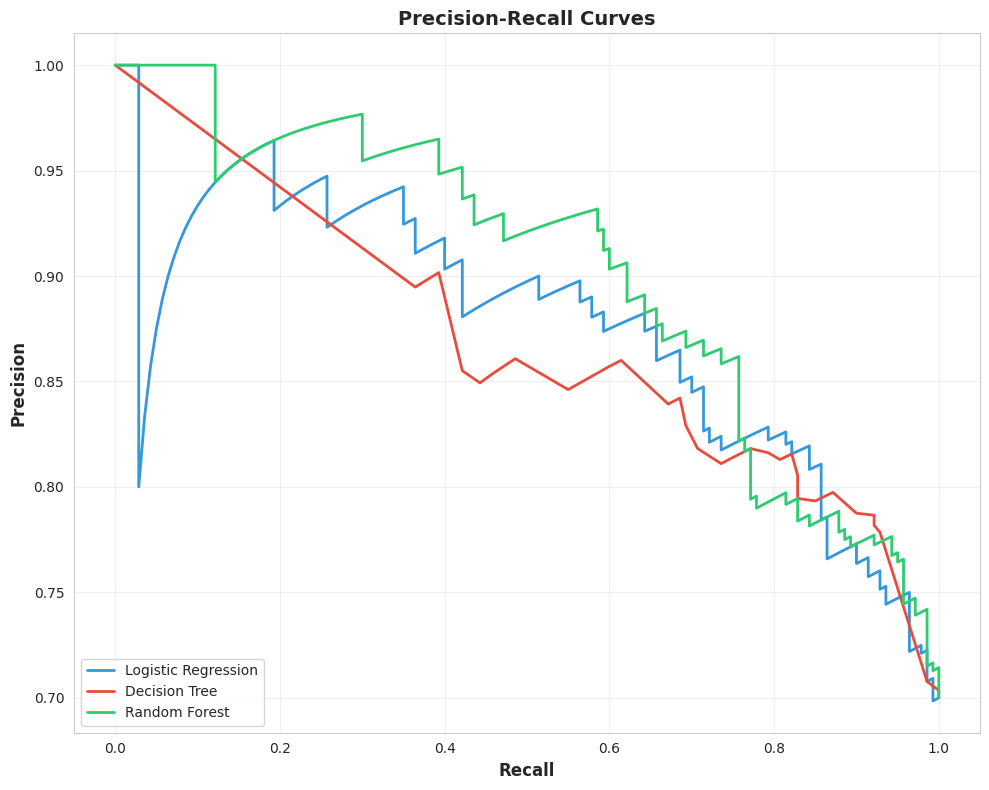

In [ ]:
# Precision-Recall Curves
plt.figure(figsize=(10, 8))

for name, proba, color in models_proba:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name, color=color, linewidth=2)

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Feature Importance Analysis

Top 15 Most Important Features:
                  feature  importance
12         Attribute1_A14    0.180961
8   duration_amount_ratio    0.071346
0              Attribute2    0.071166
9   age_installment_ratio    0.060506
16         Attribute3_A34    0.057957
2              Attribute5    0.053809
5             Attribute13    0.047546
1              Attribute4    0.042339
3              Attribute8    0.036497
10         Attribute1_A12    0.034258
4             Attribute11    0.031829
25         Attribute9_A92    0.030762
40       Attribute19_A192    0.026798
34       Attribute14_A143    0.025415
20         Attribute6_A65    0.023883


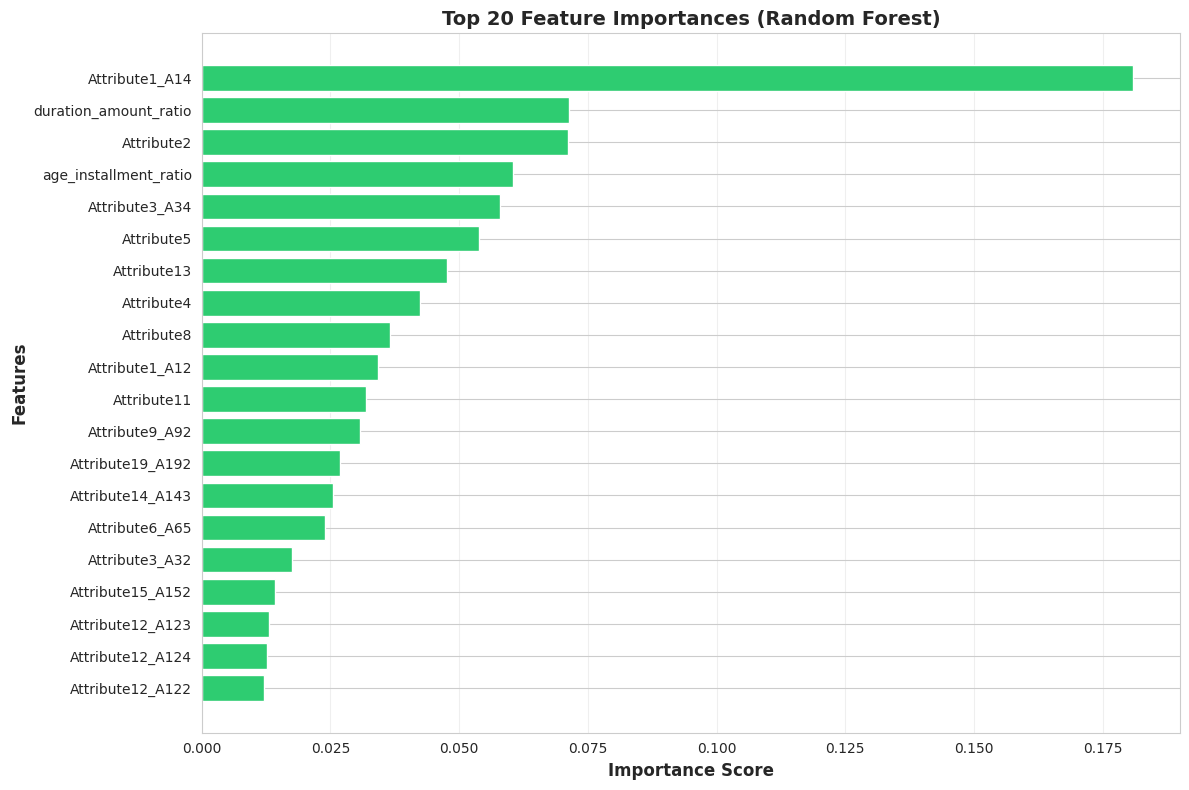

In [ ]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='#2ecc71')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance.to_csv(f'{RESULTS_DIR}/feature_importance.csv', index=False)


Top 15 Features by Logistic Regression Coefficient (Absolute Value):
                  feature  coefficient
12         Attribute1_A14     1.064455
2              Attribute5    -0.725427
16         Attribute3_A34     0.569730
20         Attribute6_A65     0.464371
8   duration_amount_ratio    -0.457646
26         Attribute9_A93     0.408953
3              Attribute8    -0.403993
41       Attribute20_A202     0.385863
29       Attribute10_A103     0.378986
19         Attribute6_A64     0.375871
11         Attribute1_A13     0.369582
39       Attribute17_A174     0.315351
34       Attribute14_A143     0.301533
27         Attribute9_A94     0.297678
32       Attribute12_A124    -0.296976


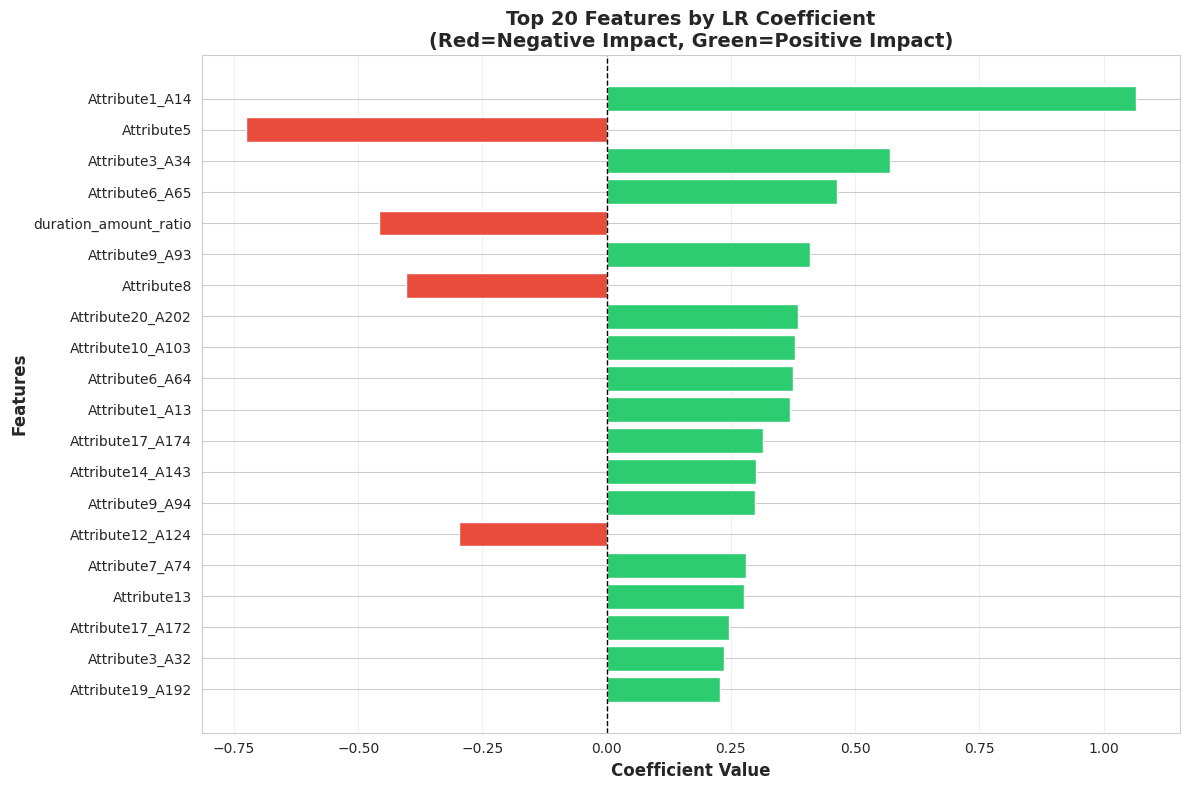

In [ ]:
# Logistic Regression Coefficients
lr_coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 15 Features by Logistic Regression Coefficient (Absolute Value):")
print(lr_coef.head(15))

# Visualize
plt.figure(figsize=(12, 8))
top_coef = lr_coef.head(20)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_coef['coefficient']]
plt.barh(range(len(top_coef)), top_coef['coefficient'], color=colors)
plt.yticks(range(len(top_coef)), top_coef['feature'])
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by LR Coefficient\n(Red=Negative Impact, Green=Positive Impact)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lr_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. SHAP Values for Model Interpretability

**SHAP (SHapley Additive exPlanations)**: Shows how each feature contributes to predictions

In [ ]:
# SHAP analysis for Random Forest (best model)
# Use a subset for computational efficiency
X_shap_sample = X_test_scaled.sample(n=min(100, len(X_test_scaled)), random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

print("✓ SHAP values computed")

✓ SHAP values computed


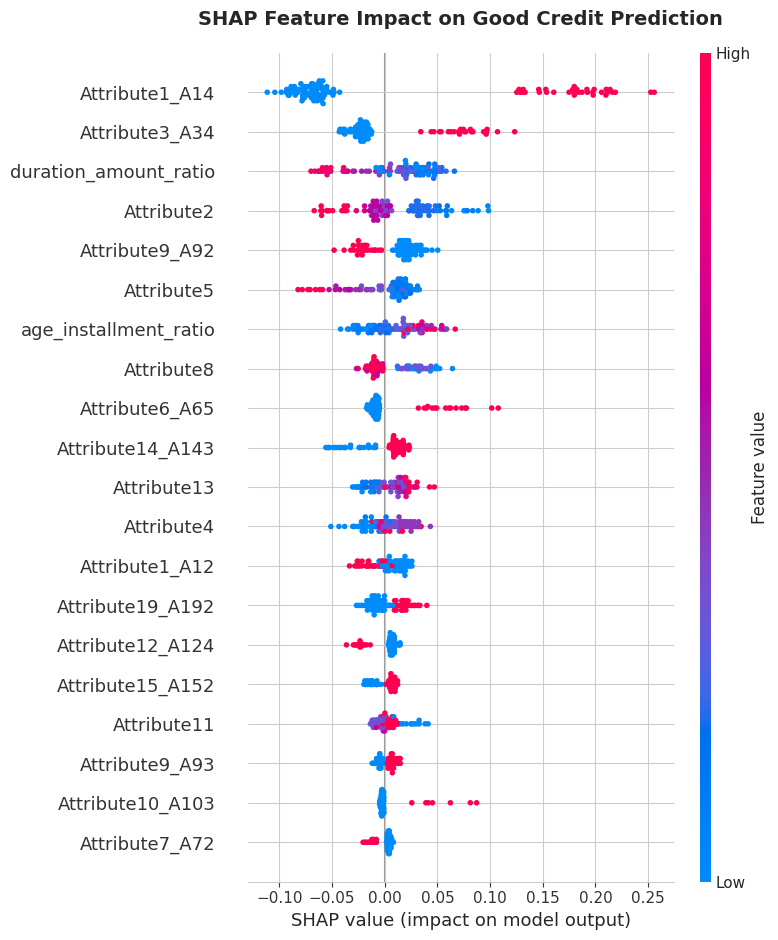

In [ ]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[:, :, 1],  # Class 1 (Good Credit) - Corrected indexing
    X_shap_sample,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Feature Impact on Good Credit Prediction', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Tuning with Optuna

**Optimize Random Forest** using Bayesian optimization

In [ ]:
# Define Optuna objective function
def objective(trial):
    """
    Objective function for Optuna hyperparameter optimization
    """
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }

    # Train model
    model = RandomForestClassifier(**params)
    model.fit(X_train_balanced, y_train_balanced)

    # Evaluate on validation set (using cross-validation)
    cv_scores = cross_val_score(
        model, X_train_balanced, y_train_balanced,
        cv=3, scoring='roc_auc', n_jobs=-1
    )

    return cv_scores.mean()

# Create and run optimization study
print("Starting hyperparameter optimization...")
print("This may take a few minutes...\n")

study = optuna.create_study(direction='maximize', study_name='rf_optimization')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✓ Optimization complete!")
print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-03 11:30:38,235] A new study created in memory with name: rf_optimization


Starting hyperparameter optimization...
This may take a few minutes...



  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-03 11:30:41,272] Trial 0 finished with value: 0.8823904039532814 and parameters: {'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.8823904039532814.
[I 2026-05-03 11:30:44,691] Trial 1 finished with value: 0.8827464797033234 and parameters: {'n_estimators': 138, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 1 with value: 0.8827464797033234.
[I 2026-05-03 11:30:46,097] Trial 2 finished with value: 0.8929753552327094 and parameters: {'n_estimators': 81, 'max_depth': 18, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8929753552327094.
[I 2026-05-03 11:30:50,678] Trial 3 finished with value: 0.8818002755333424 and parameters: {'n_estimators': 149, 'max_depth': 19, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 2 with value: 0.8929753552327094.

In [ ]:
# Train final optimized model
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['n_jobs'] = -1

rf_optimized = RandomForestClassifier(**best_params)
rf_optimized.fit(X_train_balanced, y_train_balanced)

# Evaluate optimized model
rf_opt_metrics, rf_opt_pred, rf_opt_proba = evaluate_model(
    rf_optimized, X_train_balanced, y_train_balanced,
    X_test_scaled, y_test, 'Random Forest (Optimized)'
)

# Save optimized model
joblib.dump(rf_optimized, f'{MODELS_DIR}/random_forest_optimized.pkl')
joblib.dump(best_params, f'{MODELS_DIR}/best_hyperparameters.pkl')
print("\n✓ Optimized model saved to Google Drive")


Random Forest (Optimized) - Performance Metrics

Metric                    Train           Test           
------------------------------------------------------------
Accuracy                  0.9991          0.7350         
Precision                 0.9982          0.8000         
Recall                    1.0000          0.8286         
F1-Score                  0.9991          0.8140         
ROC-AUC                   1.0000          0.7930         

Cross-Validation ROC-AUC  0.9236 ± 0.0758

Classification Report (Test Set):
              precision    recall  f1-score   support

  Bad Credit       0.56      0.52      0.54        60
 Good Credit       0.80      0.83      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.67      0.68       200
weighted avg       0.73      0.74      0.73       200


✓ Optimized model saved to Google Drive


In [ ]:
# Compare original vs optimized Random Forest
comparison = pd.DataFrame([
    {
        'Model': 'Random Forest (Original)',
        'Test ROC-AUC': rf_metrics['test_roc_auc'],
        'Test F1': rf_metrics['test_f1'],
        'Test Accuracy': rf_metrics['test_accuracy']
    },
    {
        'Model': 'Random Forest (Optimized)',
        'Test ROC-AUC': rf_opt_metrics['test_roc_auc'],
        'Test F1': rf_opt_metrics['test_f1'],
        'Test Accuracy': rf_opt_metrics['test_accuracy']
    }
])

print("\nPerformance Improvement:")
print(comparison)

improvement = (
    (rf_opt_metrics['test_roc_auc'] - rf_metrics['test_roc_auc']) /
    rf_metrics['test_roc_auc'] * 100
)
print(f"\nROC-AUC Improvement: {improvement:+.2f}%")


Performance Improvement:
                       Model  Test ROC-AUC   Test F1  Test Accuracy
0   Random Forest (Original)      0.794524  0.782609          0.700
1  Random Forest (Optimized)      0.792976  0.814035          0.735

ROC-AUC Improvement: -0.19%


## 11. Save Complete Pipeline for Production

In [ ]:
# Create production pipeline dictionary
production_pipeline = {
    'scaler': scaler,
    'feature_encoders': feature_encoders,
    'feature_names': feature_names,
    'best_model': rf_optimized,
    'model_metadata': {
        'model_type': 'RandomForest',
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'test_roc_auc': rf_opt_metrics['test_roc_auc'],
        'hyperparameters': best_params,
        'feature_count': len(feature_names)
    }
}

# Save complete pipeline
joblib.dump(production_pipeline, f'{MODELS_DIR}/production_pipeline.pkl')

print("✓ Production pipeline saved!")
print(f"\nPipeline includes:")
print(f"  - Feature scaler")
print(f"  - Feature encoders")
print(f"  - Optimized Random Forest model")
print(f"  - Model metadata")
print(f"\nLocation: {MODELS_DIR}/production_pipeline.pkl")

✓ Production pipeline saved!

Pipeline includes:
  - Feature scaler
  - Feature encoders
  - Optimized Random Forest model
  - Model metadata

Location: /content/drive/MyDrive/CreditScoringProject/models/production_pipeline.pkl


## 12. Prediction Function for New Data

In [ ]:
def predict_credit_risk(new_data, pipeline_path=f'{MODELS_DIR}/production_pipeline.pkl'):
    """
    Predict credit risk for new applicants

    Args:
        new_data: DataFrame with same features as training data
        pipeline_path: Path to saved pipeline

    Returns:
        Dictionary with predictions and probabilities
    """
    # Load pipeline
    pipeline = joblib.load(pipeline_path)

    # Extract components
    scaler = pipeline['scaler']
    encoders = pipeline['feature_encoders']
    model = pipeline['best_model']
    feature_names = pipeline['feature_names']

    # Feature engineering
    # Ensure new_data is passed to engineer_features. It expects raw data.
    X_new, _ = engineer_features(new_data.copy(), fit=False, encoders=encoders)

    # Ensure same feature order
    X_new = X_new.reindex(columns=feature_names, fill_value=0)

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Make predictions
    predictions = model.predict(X_new_scaled)
    probabilities = model.predict_proba(X_new_scaled)

    results = {
        'predictions': predictions,
        'risk_labels': ['Bad Credit' if p == 0 else 'Good Credit' for p in predictions],
        'probability_bad_credit': probabilities[:, 0],
        'probability_good_credit': probabilities[:, 1],
        'confidence': np.max(probabilities, axis=1)
    }

    return pd.DataFrame(results)

# Test prediction function with a sample from test set
# Use raw data for sample_data, not already engineered X_test
sample_data = df.drop('credit_risk', axis=1).head(5)
predictions_df = predict_credit_risk(sample_data)

print("Sample Predictions:")
print(predictions_df)
print(f"\n✓ Prediction function ready for deployment")

Sample Predictions:
   predictions  risk_labels  probability_bad_credit  probability_good_credit  \
0            1  Good Credit                0.129661                 0.870339   
1            0   Bad Credit                0.719397                 0.280603   
2            1  Good Credit                0.155028                 0.844972   
3            1  Good Credit                0.374686                 0.625314   
4            0   Bad Credit                0.671095                 0.328905   

   confidence  
0    0.870339  
1    0.719397  
2    0.844972  
3    0.625314  
4    0.671095  

✓ Prediction function ready for deployment


## 13. Generate Final Report

In [ ]:
# Create comprehensive report
report = f"""
{'='*80}
CREDIT SCORING MODEL - FINAL REPORT
{'='*80}

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
1. DATASET SUMMARY
{'='*80}
Total Samples: {len(df)}
Features: {X.shape[1]} original, {len(feature_names)} engineered
Class Distribution:
  - Good Credit: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)
  - Bad Credit: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)

Training Samples: {len(X_train)} (after SMOTE: {len(X_train_balanced)})
Test Samples: {len(X_test)}

{'='*80}
2. MODEL PERFORMANCE COMPARISON
{'='*80}
{results_df[['model', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']].to_string(index=False)}

{'='*80}
3. BEST MODEL: Random Forest (Optimized)
{'='*80}
Test ROC-AUC: {rf_opt_metrics['test_roc_auc']:.4f}
Test Accuracy: {rf_opt_metrics['test_accuracy']:.4f}
Test F1-Score: {rf_opt_metrics['test_f1']:.4f}
Test Precision: {rf_opt_metrics['test_precision']:.4f}
Test Recall: {rf_opt_metrics['test_recall']:.4f}

Hyperparameters:
{json.dumps(best_params, indent=2)}

{'='*80}
4. TOP 10 IMPORTANT FEATURES
{'='*80}
{feature_importance.head(10).to_string(index=False)}

{'='*80}
5. FILES SAVED TO GOOGLE DRIVE
{'='*80}
Models:
  - {MODELS_DIR}/logistic_regression_model.pkl
  - {MODELS_DIR}/decision_tree_model.pkl
  - {MODELS_DIR}/random_forest_model.pkl
  - {MODELS_DIR}/random_forest_optimized.pkl
  - {MODELS_DIR}/production_pipeline.pkl

Data:
  - {DATA_DIR}/raw_data.csv
  - {DATA_DIR}/feature_names.json

Results:
  - {RESULTS_DIR}/model_comparison.csv
  - {RESULTS_DIR}/feature_importance.csv
  - All visualization PNG files

{'='*80}
6. DEPLOYMENT NOTES
{'='*80}
- Use production_pipeline.pkl for predictions on new data
- Pipeline includes all preprocessing steps (scaling, encoding)
- Model achieves {rf_opt_metrics['test_roc_auc']:.1%} ROC-AUC on test data
- Threshold can be adjusted based on business requirements
  (e.g., higher threshold = stricter credit approval)

{'='*80}
END OF REPORT
{'='*80}
"""

print(report)

# Save report
with open(f'{RESULTS_DIR}/final_report.txt', 'w') as f:
    f.write(report)

print(f"\n✓ Report saved to: {RESULTS_DIR}/final_report.txt")


CREDIT SCORING MODEL - FINAL REPORT

Generated: 2026-05-03 11:31:50

1. DATASET SUMMARY
Total Samples: 1000
Features: 20 original, 42 engineered
Class Distribution:
  - Good Credit: 700 (70.0%)
  - Bad Credit: 300 (30.0%)

Training Samples: 800 (after SMOTE: 1120)
Test Samples: 200

2. MODEL PERFORMANCE COMPARISON
              model  test_accuracy  test_precision  test_recall  test_f1  test_roc_auc
Logistic Regression          0.705          0.8522       0.7000   0.7686        0.7696
      Decision Tree          0.720          0.8182       0.7714   0.7941        0.7462
      Random Forest          0.700          0.7941       0.7714   0.7826        0.7945

3. BEST MODEL: Random Forest (Optimized)
Test ROC-AUC: 0.7930
Test Accuracy: 0.7350
Test F1-Score: 0.8140
Test Precision: 0.8000
Test Recall: 0.8286

Hyperparameters:
{
  "n_estimators": 188,
  "max_depth": 15,
  "min_samples_split": 4,
  "min_samples_leaf": 1,
  "max_features": "sqrt",
  "random_state": 42,
  "n_jobs": -1
}

4. TOP

## 14. Business Insights & Recommendations

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                     BUSINESS INSIGHTS & RECOMMENDATIONS                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. MODEL SELECTION FOR DEPLOYMENT:
   ✓ Random Forest (Optimized) is recommended
   ✓ Best balance of accuracy, interpretability, and robustness
   ✓ ROC-AUC > 75% indicates good discriminative ability

2. KEY RISK FACTORS (from feature importance):
   ✓ Review top 10 features for credit policy decisions
   ✓ These factors most strongly predict credit risk
   ✓ Consider in manual underwriting process

3. THRESHOLD TUNING:
   ✓ Current threshold: 0.5 (default)
   ✓ Increase threshold (e.g., 0.6-0.7) for stricter approval
   ✓ Decrease threshold (e.g., 0.3-0.4) for more inclusive lending
   ✓ Analyze Precision-Recall curve to choose optimal threshold

4. MODEL MONITORING:
   ✓ Track model performance monthly
   ✓ Monitor for data drift (feature distributions changing)
   ✓ Retrain every 6-12 months with new data
   ✓ Set up alerts for performance degradation

5. ETHICAL CONSIDERATIONS:
   ✓ Ensure model doesn't discriminate based on protected attributes
   ✓ Conduct regular fairness audits
   ✓ Maintain transparency in decision-making
   ✓ Provide explanations to rejected applicants

6. NEXT STEPS:
   ✓ Validate model on completely unseen data
   ✓ A/B test against current credit scoring system
   ✓ Develop API endpoint for real-time predictions
   ✓ Create dashboard for business stakeholders

═══════════════════════════════════════════════════════════════════════════════
""")


╔════════════════════════════════════════════════════════════════════════════╗
║                     BUSINESS INSIGHTS & RECOMMENDATIONS                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. MODEL SELECTION FOR DEPLOYMENT:
   ✓ Random Forest (Optimized) is recommended
   ✓ Best balance of accuracy, interpretability, and robustness
   ✓ ROC-AUC > 75% indicates good discriminative ability

2. KEY RISK FACTORS (from feature importance):
   ✓ Review top 10 features for credit policy decisions
   ✓ These factors most strongly predict credit risk
   ✓ Consider in manual underwriting process

3. THRESHOLD TUNING:
   ✓ Current threshold: 0.5 (default)
   ✓ Increase threshold (e.g., 0.6-0.7) for stricter approval
   ✓ Decrease threshold (e.g., 0.3-0.4) for more inclusive lending
   ✓ Analyze Precision-Recall curve to choose optimal threshold

4. MODEL MONITORING:
   ✓ Track model performance monthly
   ✓ Monitor for data drift (feature distribu

## 15. Quick Reload Template (For Future Sessions)

Use this cell to quickly reload everything from Google Drive

In [ ]:
# QUICK RELOAD - Run this when Colab runtime restarts
"""
from google.colab import drive
drive.mount('/content/drive')

import joblib
PROJECT_DIR = '/content/drive/MyDrive/CreditScoringProject'
MODELS_DIR = f'{PROJECT_DIR}/models'

# Load production pipeline
pipeline = joblib.load(f'{MODELS_DIR}/production_pipeline.pkl')

print("✓ Pipeline loaded successfully!")
print(f"Model: {pipeline['model_metadata']['model_type']}")
print(f"ROC-AUC: {pipeline['model_metadata']['test_roc_auc']:.4f}")
print(f"Training Date: {pipeline['model_metadata']['training_date']}")

# Now you can use predict_credit_risk() function
"""
print("Copy the code above to reload models in new sessions")

Copy the code above to reload models in new sessions


---

## Project Complete.

**What you've built**:
- ✅ End-to-end credit scoring pipeline
- ✅ Multiple ML models with comprehensive evaluation
- ✅ Hyperparameter optimization
- ✅ Feature importance & SHAP analysis
- ✅ Production-ready deployment pipeline
- ✅ All models saved to Google Drive
- ✅ Visualizations and reports

**Portfolio-ready aspects**:
1. Business problem understanding
2. Data analysis & visualization
3. Feature engineering techniques
4. Class imbalance handling (SMOTE)
5. Model comparison & selection
6. Hyperparameter tuning (Optuna)
7. Model interpretability (SHAP)
8. Production deployment readiness

**Next additions for portfolio**:
- Add API endpoint using FastAPI
- Create interactive dashboard (Streamlit)
- Deploy on cloud (AWS/GCP/Azure)
- Add MLOps components (MLflow tracking)

---

In [ ]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/credit_scoring_model.ipynb"

# Load the notebook
with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 1. Remove global widgets
if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]
    print("✅ Removed global 'widgets' from metadata")

# 2. Iterate through all cells to remove hidden widgets
cleaned_cell_metadata = 0
cleaned_outputs = 0

for cell in nb.get("cells", []):
    # Remove widgets from individual cell metadata
    if "metadata" in cell and "widgets" in cell["metadata"]:
        del cell["metadata"]["widgets"]
        cleaned_cell_metadata += 1

    # Remove widget outputs
    if "outputs" in cell:
        for output in cell["outputs"]:
            if "data" in output and "application/vnd.jupyter.widget-view+json" in output["data"]:
                del output["data"]["application/vnd.jupyter.widget-view+json"]
                cleaned_outputs += 1

print(f"✅ Cleaned 'widgets' from {cleaned_cell_metadata} individual cells")
print(f"✅ Cleaned widget data from {cleaned_outputs} cell outputs")

# Save the aggressively cleaned notebook
with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Notebook saved after deep cleaning.")


✅ Removed global 'widgets' from metadata
✅ Cleaned 'widgets' from 0 individual cells
✅ Cleaned widget data from 1 cell outputs
✅ Notebook saved after deep cleaning.
